# Experiment 5: Cohen–Sutherland Line Clipping Algorithm

**Name:** Ojas B A  
**USN:** 1RVU23CSE321  
**Course:** Computer Graphics and Virtual Reality

This notebook keeps the implementation minimal: the algorithm is written in **C++**, and Python is used only to display the final clipping result in Colab.

In [1]:
%%writefile cohen.cpp
#include <iostream>
using namespace std;

const int INSIDE=0, LEFT=1, RIGHT=2, BOTTOM=4, TOP=8;
double xmin=100, ymin=100, xmax=300, ymax=300;

int code(double x, double y){
    int c=INSIDE;
    if(x<xmin) c|=LEFT; else if(x>xmax) c|=RIGHT;
    if(y<ymin) c|=BOTTOM; else if(y>ymax) c|=TOP;
    return c;
}

bool clip(double &x1,double &y1,double &x2,double &y2){
    int c1=code(x1,y1), c2=code(x2,y2);
    while(true){
        if((c1|c2)==0) return true;
        if(c1&c2) return false;

        int out = c1 ? c1 : c2;
        double x,y;

        if(out & TOP){
            x=x1+(x2-x1)*(ymax-y1)/(y2-y1); y=ymax;
        } else if(out & BOTTOM){
            x=x1+(x2-x1)*(ymin-y1)/(y2-y1); y=ymin;
        } else if(out & RIGHT){
            y=y1+(y2-y1)*(xmax-x1)/(x2-x1); x=xmax;
        } else {
            y=y1+(y2-y1)*(xmin-x1)/(x2-x1); x=xmin;
        }

        if(out==c1){ x1=x; y1=y; c1=code(x1,y1); }
        else { x2=x; y2=y; c2=code(x2,y2); }
    }
}

int main(){
    double x1=50, y1=150, x2=350, y2=250;
    cout << x1 << " " << y1 << " " << x2 << " " << y2 << "\n";
    if(clip(x1,y1,x2,y2))
        cout << x1 << " " << y1 << " " << x2 << " " << y2 << "\n";
    else
        cout << "REJECTED\n";
    return 0;
}


Writing cohen.cpp


In [2]:
# Compile and run (no installation needed)
!g++ cohen.cpp -o cohen
output = !./cohen
print("Original line :", output[0])
print("Clipped line  :", output[1])

Original line : 50 150 350 250
Clipped line  : 100 166.667 300 233.333


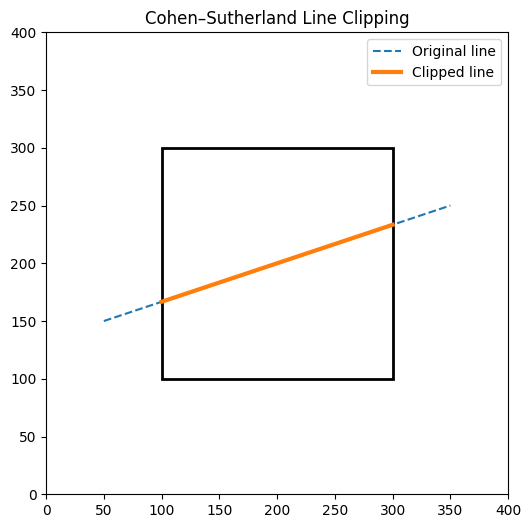

In [3]:
# Simple output figure for the lab screenshot
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

orig = list(map(float, output[0].split()))
clipd = list(map(float, output[1].split()))

fig, ax = plt.subplots(figsize=(6,6))
ax.add_patch(Rectangle((100,100),200,200,fill=False,linewidth=2))
ax.plot([orig[0],orig[2]],[orig[1],orig[3]],'--',label='Original line')
ax.plot([clipd[0],clipd[2]],[clipd[1],clipd[3]],linewidth=3,label='Clipped line')
ax.set_xlim(0,400); ax.set_ylim(0,400)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Cohen–Sutherland Line Clipping')
plt.show()

## Result
The Cohen–Sutherland line clipping algorithm was implemented successfully.